In [1]:
from typing import List
from pathlib import Path
import pickle

from PIL import Image, ImageOps
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.utils.visualizer import Visualizer, ColorMode

/home/abhinavchadaga/CS/fri_II/.venv/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path_to_dataset = "./dataset/annotated_building_imgs/"
dataset_name = "annotated elevator images"

In [3]:
from pathlib import PosixPath


def register_dataset():
    """ Define function to register 
        our custom dataset using the specified buildings
    """
    dataset = list()
    for building in Path(path_to_dataset).iterdir():
        for img_path in building.iterdir():
            with img_path.open("rb") as img:
                dataset.append(pickle.load(img))


    return dataset

In [4]:
thing_classes = ["label", "button", "not button"]

label_color = (152, 168, 248)
button_color = (188, 206, 248)
not_button_color = (255, 148, 148) 

thing_colors = [label_color, button_color, not_button_color]

DatasetCatalog.register(dataset_name, register_dataset)
MetadataCatalog.get(dataset_name).thing_classes = thing_classes
MetadataCatalog.get(dataset_name).thing_colors = thing_colors
dataset: List[dict] = DatasetCatalog.get(dataset_name)

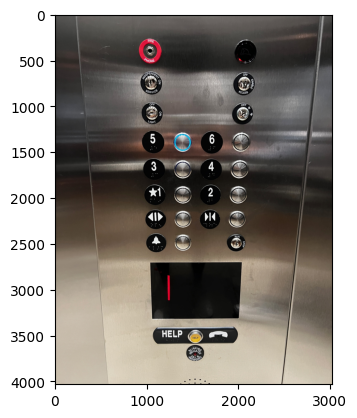

In [5]:
import random


idx = random.randint(0, len(dataset) - 1)

img_dict = dataset[15]
img = Image.open(img_dict['file_name'])
img = ImageOps.exif_transpose(img)
plt.imshow(img)

In [6]:
v = Visualizer(img_rgb=img, metadata=MetadataCatalog.get(dataset_name), instance_mode=ColorMode.SEGMENTATION, scale=0.50)
annotations = v.draw_dataset_dict(dic=img_dict).get_image()
# plt.imshow(annotations)
cv2.imwrite("output.png", annotations)

True